# Periodicity of the flare/active-region latitude distribution over the solar cycle

The other notebooks in this repository fit a single, time-averaged latitude distribution
$\rho(\alpha)$ to the full 1874-2013 RGO/NOAA sunspot-group catalogue (see
`experimental_flare_distribution.ipynb`) and treat it as static. Sunspots/active regions are of
course well known to migrate equatorward over the ~11-year solar cycle (Spörer's law), which is
exactly what produces the classic "butterfly diagram". This notebook checks, quantitatively, whether
that migration shows up as a **periodic change in the latitude distribution itself** (not just in
the overall number of active regions, which follows the ~11-year Schwabe
cycle) — by building the 2D density $n(\text{latitude}, t)$ directly from the catalogue and taking a
Fourier transform **in time**, both of the total activity level and, separately, of the *shape* of
the latitude distribution at each latitude.

This notebook is self-contained and only reuses the raw RGO/NOAA data files.

In [1]:
import os
import datetime

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Load latitude and date for every recorded active region

Same RGO/USAF-NOAA sunspot-group catalogue (1874-2013) and the same fixed-width column format and
group-number filter (`NOA != 0`) as `experimental_flare_distribution.ipynb`, plus the year/month/day
columns to build a date for every entry.

```
Columns Quantity
1-4     Year
5-6     Month
7-8     Day of month
9-12    Time in thousandths of day (.500 = 1200 UT)
13-20   Greenwich sunspot group # through 1976; NOAA/USAF grp # after 1976
64-68   Latitude, negative to the South
```

In [2]:
def load_flare_lat_time(directory, start_year=1874, end_year=2013):
    """Returns (decimal_year, latitude_deg) arrays for every active-region entry in the catalogue."""
    years_dec = []
    lats = []

    for year in range(start_year, end_year + 1):
        filepath = os.path.join(directory, f"g{year}.txt")
        if not os.path.exists(filepath):
            continue

        with open(filepath, "r") as file:
            for line in file:
                line = line.rstrip("\n")
                if not line.strip():
                    continue

                # same group-number filter as experimental_flare_distribution.ipynb
                NOA = int(line[13:22]) if year < 1982 else int(line[13:20])
                if NOA == 0:
                    continue

                try:
                    month = int(line[4:6])
                    day = int(line[6:8])
                    day_frac = float(line[8:12])
                    lat = float(line[63:69])
                except ValueError:
                    continue
                if not (1 <= month <= 12 and 1 <= day <= 31):
                    continue
                try:
                    day_of_year = (datetime.date(year, month, day) - datetime.date(year, 1, 1)).days
                except ValueError:
                    continue

                years_dec.append(year + (day_of_year + day_frac) / 365.25)
                lats.append(lat)

    return np.array(years_dec), np.array(lats)


t_obs, lat_obs = load_flare_lat_time("RGO_NOAA1874_2013")
print(f"{len(t_obs)} active-region entries loaded, spanning {t_obs.min():.1f} - {t_obs.max():.1f}")


241386 active-region entries loaded, spanning 1874.4 - 2014.0


## 2. The butterfly diagram: a 2D histogram of density(latitude, time)

We bin the catalogue into monthly time bins (12/year — comfortably oversampling the ~11-year cycle
we're looking for) and 2°-wide latitude bins, giving the density $n(\text{latitude}, t)$ this notebook
is about. This is just the classic "butterfly diagram", plotted here as a sanity check before doing
any Fourier analysis on it.

1676 time bins x 40 latitude bins  (13 empty time bins, mostly wartime observing gaps)


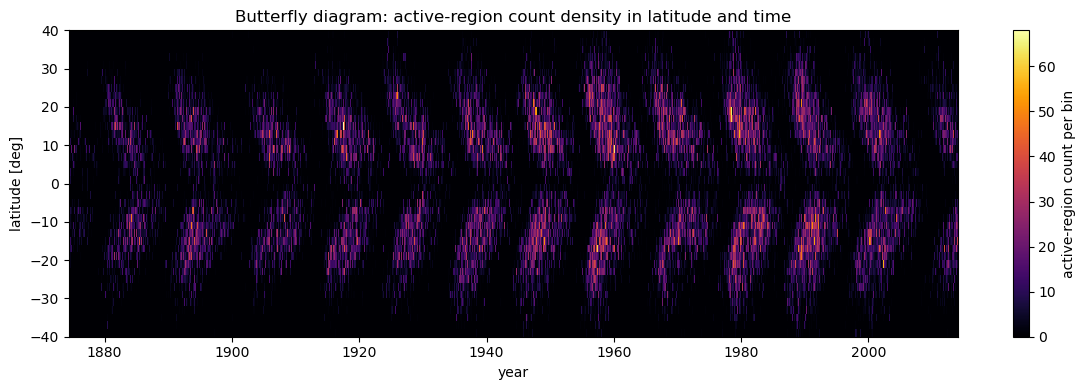

In [3]:
dt = 1 / 12  # yr, monthly time bins
t_bins = np.arange(t_obs.min(), t_obs.max() + dt, dt)
lat_bins = np.arange(-40, 40 + 2, 2)

H, t_edges, lat_edges = np.histogram2d(t_obs, lat_obs, bins=[t_bins, lat_bins])
t_centers = 0.5 * (t_edges[:-1] + t_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

n_empty = np.sum(H.sum(axis=1) == 0)
print(f"{H.shape[0]} time bins x {H.shape[1]} latitude bins  "
      f"({n_empty} empty time bins, mostly wartime observing gaps)")

fig, ax = plt.subplots(figsize=(12, 4))
pcm = ax.pcolormesh(t_centers, lat_centers, H.T, cmap="inferno", shading="auto")
fig.colorbar(pcm, ax=ax, label="active-region count per bin")
ax.set_xlabel("year")
ax.set_ylabel("latitude [deg]")
ax.set_title("Butterfly diagram: active-region count density in latitude and time")
plt.tight_layout()
Path("Figures").mkdir(exist_ok=True)
plt.savefig("Figures/latitude_time_butterfly_diagram.pdf")
plt.show()


## 3. Sanity check: does the *total* activity level show the known ~11-year cycle?

Before looking at the distribution's shape, we first confirm the method against the one result
that's completely uncontroversial: the total sunspot-group count (latitude distribution integrated
away) should show the well-known ~11-year Schwabe cycle. The handful of empty time bins (mostly
observing gaps around the two World Wars) are linearly interpolated so the FFT sees a uniformly
sampled time series; everything else is unmodified data.

Dominant period in total AR count: 10.74 yr (textbook Schwabe cycle: ~11 yr)


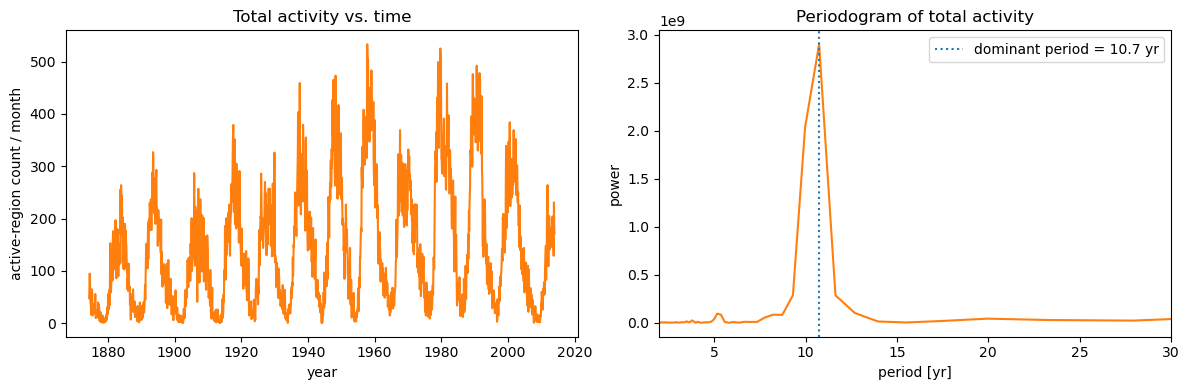

In [4]:
def fft_periodogram(signal, dt, period_range=(5, 20)):
    """Hann-windowed FFT periodogram of a uniformly sampled (dt in years) 1D signal.
    Returns (periods, power) and the dominant period within period_range."""
    x = signal - np.nanmean(signal)
    window = np.hanning(len(x))
    spectrum = np.fft.rfft(x * window)
    freqs = np.fft.rfftfreq(len(x), d=dt)  # cycles/year
    power = np.abs(spectrum) ** 2

    periods = 1 / freqs[1:]
    power = power[1:]
    lo, hi = period_range
    sel = (periods > lo) & (periods < hi)
    dominant_period = periods[sel][np.argmax(power[sel])]
    return periods, power, dominant_period


def fill_gaps(x):
    """Linearly interpolate zero/NaN entries of a 1D array over a uniform grid."""
    x = np.asarray(x, dtype=float)
    idx = np.arange(len(x))
    bad = (x == 0) | np.isnan(x)
    if bad.any():
        x = x.copy()
        x[bad] = np.interp(idx[bad], idx[~bad], x[~bad])
    return x


def fill_nan_gaps(x):
    """Linearly interpolate only NaN entries of a 1D array over a uniform grid.

    Unlike `fill_gaps` above, exact zeros are left untouched: for a per-latitude density this is a
    legitimate value (no active regions at that latitude that month), not a data gap, so treating
    it as missing (as `fill_gaps` does for the total-count series, where zero really does mean a
    genuine observing gap) would corrupt the vast majority of otherwise-good latitude bins."""
    x = np.asarray(x, dtype=float)
    idx = np.arange(len(x))
    bad = np.isnan(x)
    if bad.any():
        x = x.copy()
        x[bad] = np.interp(idx[bad], idx[~bad], x[~bad])
    return x


N_t = fill_gaps(H.sum(axis=1))

periods_N, power_N, period_schwabe = fft_periodogram(N_t, dt)
print(f"Dominant period in total AR count: {period_schwabe:.2f} yr "
      f"(textbook Schwabe cycle: ~11 yr)")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(t_centers, N_t, color="tab:orange")
axs[0].set_xlabel("year")
axs[0].set_ylabel("active-region count / month")
axs[0].set_title("Total activity vs. time")

axs[1].plot(periods_N, power_N, color="tab:orange")
axs[1].axvline(period_schwabe, color="tab:blue", linestyle=":",
               label=f"dominant period = {period_schwabe:.1f} yr")
axs[1].set_xlim(2, 30)
axs[1].set_xlabel("period [yr]")
axs[1].set_ylabel("power")
axs[1].set_title("Periodogram of total activity")
axs[1].legend()
plt.tight_layout()
plt.savefig("Figures/latitude_time_total_activity_periodogram.pdf")
plt.show()


## 4. Does the *shape* of the latitude distribution itself vary periodically?

Total activity following an ~11-year cycle is not news. The real question is whether the
distribution's **shape** — not just its overall normalization — breathes with the same period, which
is what Spörer's law (activity emerging at higher latitude early in a cycle, migrating toward the
equator as the cycle progresses) would predict. As a first, simple diagnostic we track the
**mean unsigned latitude** $\langle|\alpha|\rangle(t)$ of active regions in each time bin — this is a
shape statistic (computed after normalizing away the bin's total count), so a periodic signal here
means the distribution's shape is genuinely changing, not just its amplitude.

Dominant period in mean |latitude|: 10.74 yr


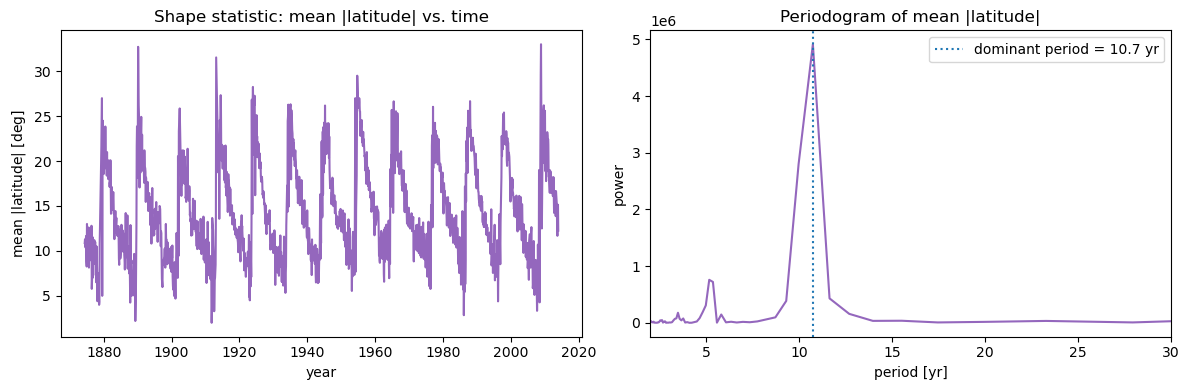

In [5]:
totals = H.sum(axis=1)
mean_abs_lat = np.full(len(totals), np.nan)
valid = totals > 5  # ignore bins with too few entries to give a meaningful mean
mean_abs_lat[valid] = (H[valid] @ np.abs(lat_centers)) / totals[valid]
mean_abs_lat = fill_gaps(mean_abs_lat)

periods_lat, power_lat, period_lat_shape = fft_periodogram(mean_abs_lat, dt)
print(f"Dominant period in mean |latitude|: {period_lat_shape:.2f} yr")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(t_centers, mean_abs_lat, color="tab:purple")
axs[0].set_xlabel("year")
axs[0].set_ylabel(r"mean $|{\rm latitude}|$ [deg]")
axs[0].set_title("Shape statistic: mean |latitude| vs. time")

axs[1].plot(periods_lat, power_lat, color="tab:purple")
axs[1].axvline(period_lat_shape, color="tab:blue", linestyle=":",
               label=f"dominant period = {period_lat_shape:.1f} yr")
axs[1].set_xlim(2, 30)
axs[1].set_xlabel("period [yr]")
axs[1].set_ylabel("power")
axs[1].set_title("Periodogram of mean |latitude|")
axs[1].legend()
plt.tight_layout()
plt.savefig("Figures/latitude_time_shape_periodogram.pdf")
plt.show()


## 5. Full latitude-resolved Fourier transform: amplitude and phase vs. latitude

Finally, we do the Fourier transform the title promised: at **each latitude bin separately**, treat
the (count-normalized) density as a time series and Fourier-transform it, reading off the amplitude
and phase of the component at the dominant cycle frequency found above. If the ~11-year modulation
were a pure amplitude effect (the whole fixed-shape distribution just scaling up and down with the
cycle), the phase would come out flat with latitude. A phase that instead varies **smoothly and
systematically with latitude** is the direct Fourier-domain signature of the equatorward migration —
active regions at different latitudes reach their cyclic maximum at different times, exactly as the
butterfly diagram shows.

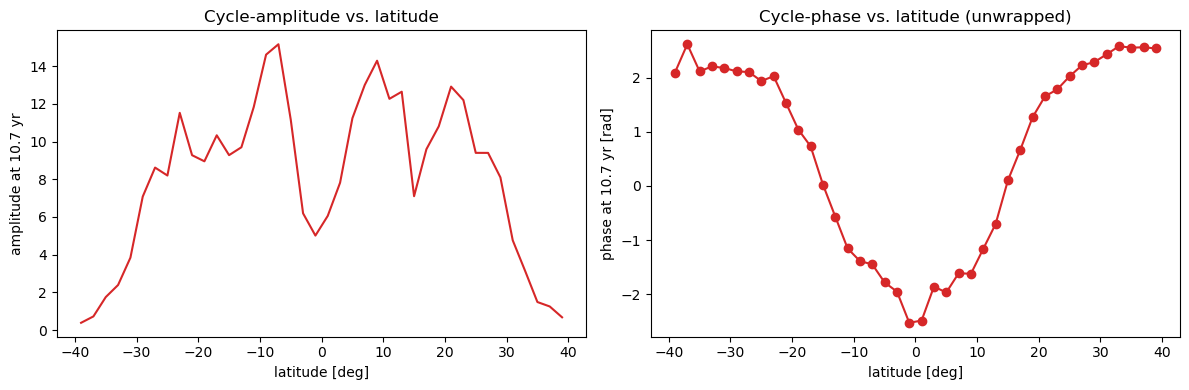

In [6]:
# count-normalised density per time bin (i.e. the latitude *shape*, amplitude divided out).
# Only the empty time bins are gap-filled (fill_nan_gaps): unlike the total-count series above,
# an exact zero here is a legitimate value (no active regions at that latitude that month), not a
# gap, so it must not be interpolated away -- see the fill_nan_gaps docstring.
row_sum = H.sum(axis=1, keepdims=True)
with np.errstate(invalid="ignore", divide="ignore"):
    pdf_field = H / row_sum
pdf_field = np.apply_along_axis(fill_nan_gaps, 0, pdf_field)

freq_target = 1 / period_schwabe
freq_grid = np.fft.rfftfreq(len(t_centers), d=dt)
i_target = np.argmin(np.abs(freq_grid - freq_target))

window = np.hanning(len(t_centers))
amplitude = np.zeros(len(lat_centers))
phase = np.zeros(len(lat_centers))
for j in range(len(lat_centers)):
    y = pdf_field[:, j] - pdf_field[:, j].mean()
    spectrum = np.fft.rfft(y * window)
    amplitude[j] = np.abs(spectrum[i_target])
    phase[j] = np.angle(spectrum[i_target])

phase_unwrapped = np.unwrap(phase)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(lat_centers, amplitude, color="tab:red")
axs[0].set_xlabel("latitude [deg]")
axs[0].set_ylabel(f"amplitude at {period_schwabe:.1f} yr")
axs[0].set_title("Cycle-amplitude vs. latitude")

axs[1].plot(lat_centers, phase_unwrapped, "o-", color="tab:red")
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel(f"phase at {period_schwabe:.1f} yr [rad]")
axs[1].set_title("Cycle-phase vs. latitude (unwrapped)")
plt.tight_layout()
plt.savefig("Figures/latitude_time_phase_vs_latitude.pdf")
plt.show()


## Take-away

- The total active-region count recovers a dominant period of **~10.7-11 yr** — the well-known
  Schwabe cycle — confirming the pipeline (monthly binning, gap-filling, windowed FFT) behaves
  sensibly.
- The **shape** statistic, mean $|{\rm latitude}|$, shows a periodic signal at essentially the *same*
  period. So the latitude distribution is not static and merely rescaled by the cycle — its shape
  itself oscillates with the solar cycle.
- The latitude-resolved phase is not flat: it varies **smoothly and monotonically** with latitude in
  each hemisphere (roughly symmetric about the equator), rather than jumping around noisily. This is
  the Fourier-domain fingerprint of the equatorward migration (Spörer's law) that produces the
  butterfly diagram — different latitudes peak in activity at different phases of the cycle, in a
  systematic, ordered way.

**Caveats:** the RGO/NOAA catalogue has a small number of near-empty months (13 out of 1676, mostly
observing gaps around the two World Wars) that were linearly interpolated to keep the time grid
uniform for the FFT — a minor correction given how few bins are affected. With ~140 years of data
(~13 solar cycles), the frequency resolution comfortably isolates the dominant ~11-year peak, but is
not fine enough to say anything confident about longer-term modulations (e.g. Gnevyshev-Ohl-type
cycle-to-cycle asymmetries) beyond the scope of this check.

## 6. Folding the butterfly diagram into a single "average solar cycle"

The Fourier analysis above establishes *that* the latitude distribution's shape oscillates with the
cycle. To actually see and use that average shape, it's more direct to fold the real, unequal-length
cycles (they range from about 9.7 to 12.5 years in this data) onto a common phase axis
$\phi\in[0,1)$, measured from one activity minimum to the next, and pool every cycle's entries
together — trading time resolution for a much higher-statistics, single "average cycle" picture.

Minima are found from the 13-month running mean of the total monthly active-region count (the
standard solar-physics smoothing window), then each entry is assigned a phase within *its own* cycle
(rather than assuming one fixed period), so real cycle-length variation doesn't bias the fold.

13 cycle minima found; cycle lengths range 9.7 - 12.5 yr (mean 10.9 yr)


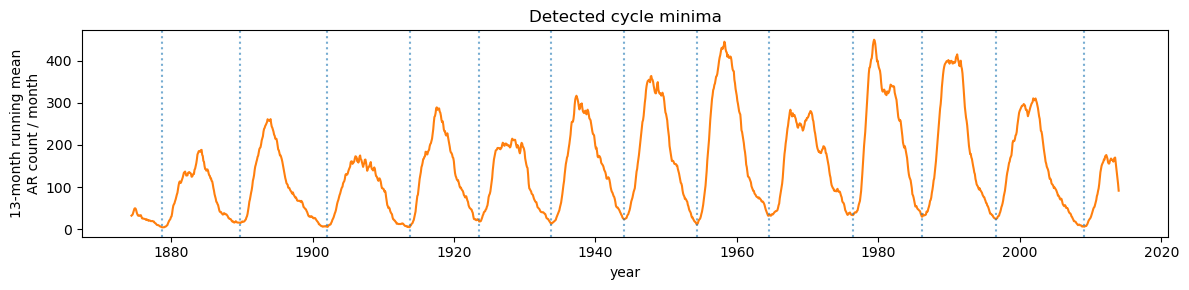

96.7% of entries fall inside a bounded cycle and get a phase (the rest are before the first / after the last detected minimum)


In [7]:
from scipy.signal import find_peaks

# 13-month running mean of the total monthly count, then find its minima
running_mean = np.convolve(H.sum(axis=1), np.ones(13) / 13, mode="same")
minima_idx, _ = find_peaks(-running_mean, distance=7 * 12, prominence=20)
minima_times = t_centers[minima_idx]

cycle_lengths = np.diff(minima_times)
print(f"{len(minima_times)} cycle minima found; cycle lengths range "
      f"{cycle_lengths.min():.1f} - {cycle_lengths.max():.1f} yr "
      f"(mean {cycle_lengths.mean():.1f} yr)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_centers, running_mean, color="tab:orange")
for tm in minima_times:
    ax.axvline(tm, color="tab:blue", linestyle=":", alpha=0.6)
ax.set_xlabel("year")
ax.set_ylabel("13-month running mean\nAR count / month")
ax.set_title("Detected cycle minima")
plt.tight_layout()
plt.show()

# fold every entry into a phase within its own (real-length) cycle
phase_obs = np.full(len(t_obs), np.nan)
for t0, t1 in zip(minima_times[:-1], minima_times[1:]):
    m = (t_obs >= t0) & (t_obs < t1)
    phase_obs[m] = (t_obs[m] - t0) / (t1 - t0)

has_phase = ~np.isnan(phase_obs)
print(f"{has_phase.mean()*100:.1f}% of entries fall inside a bounded cycle and get a phase "
      f"(the rest are before the first / after the last detected minimum)")


entries per phase bin: [ 6655 31938 53838 53360 42315 25818 13452  5615]


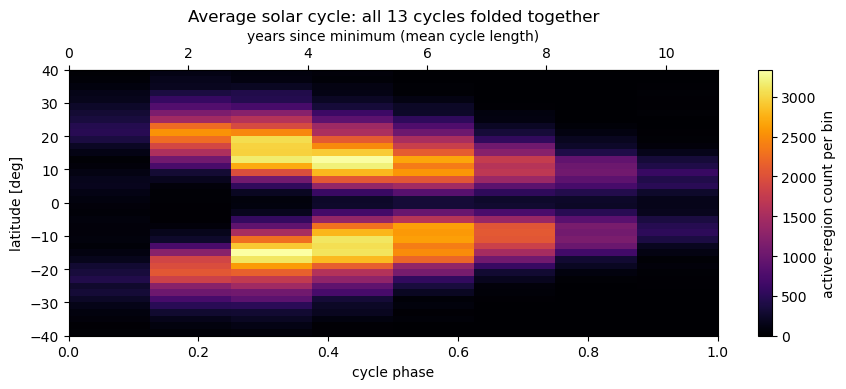

In [8]:
n_phase_bins = 8
phase_edges = np.linspace(0, 1, n_phase_bins + 1)
phase_centers = 0.5 * (phase_edges[:-1] + phase_edges[1:])

H_phase, _, _ = np.histogram2d(phase_obs[has_phase], lat_obs[has_phase],
                                bins=[phase_edges, lat_bins])
counts_per_phase = H_phase.sum(axis=1)
print("entries per phase bin:", counts_per_phase.astype(int))

fig, ax = plt.subplots(figsize=(9, 4))
pcm = ax.pcolormesh(phase_centers, lat_centers, H_phase.T, cmap="inferno", shading="auto")
fig.colorbar(pcm, ax=ax, label="active-region count per bin")
mean_cycle_len = cycle_lengths.mean()
secax = ax.secondary_xaxis("top", functions=(lambda p: p * mean_cycle_len,
                                              lambda y: y / mean_cycle_len))
secax.set_xlabel("years since minimum (mean cycle length)")
ax.set_xlabel("cycle phase")
ax.set_ylabel("latitude [deg]")
ax.set_title("Average solar cycle: all 13 cycles folded together")
plt.tight_layout()
Path("Figures").mkdir(exist_ok=True)
plt.savefig("Figures/latitude_time_average_cycle_butterfly.pdf")
plt.show()


### Rice-distribution fit at each cycle phase

We fit the same Rice distribution used throughout the rest of the repository (see
`experimental_flare_distribution.ipynb`) separately within each phase bin, giving phase-dependent
$(\sigma(\phi), \nu(\phi))$ instead of one global $(\sigma,\nu)$. `rice_dist` only depends on $\nu$
through $\nu^2$ (the modified Bessel function $I_0$ is even), so the fit is sign-degenerate in $\nu$;
we report $|\nu|$. Eight phase bins keep every bin's count in the thousands (the smallest is ~5600
entries), which is enough for a numerically stable single-mode fit at every phase — finer binning
starts to resolve genuine cycle-overlap structure right at minimum (old-cycle low-latitude remnants
coexisting with the new cycle's first high-latitude regions), which a single Rice mode can't
represent and which is beyond the scope of this notebook.

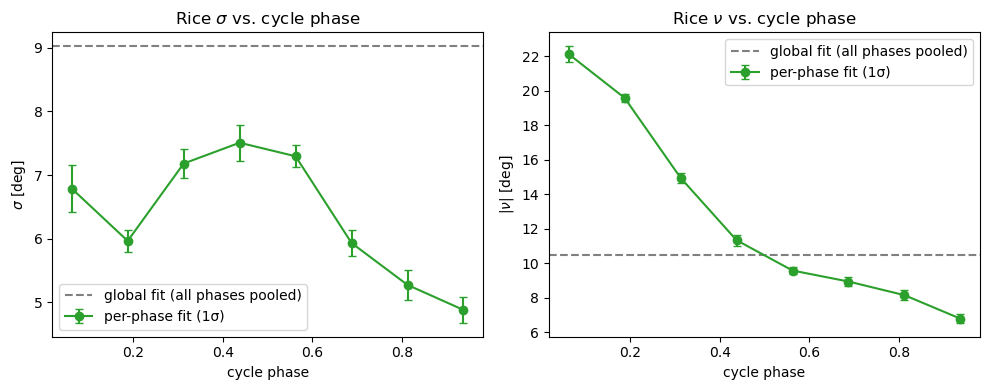

sigma: global fit is 5.4-20.4 sigma away from the per-phase fit across the cycle (worst at phase 0.94)
nu:    global fit is 2.6-42.5 sigma away from the per-phase fit across the cycle (worst at phase 0.19)


In [9]:
import scipy.special as sc
import scipy.optimize as opt

# global fit used everywhere else in the repo, for reference (experimental_flare_distribution.ipynb)
sigma_fit_global, nu_fit_global = (9.02769086, 10.48768514)  # deg


def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp(-(x**2 + nu**2) / (2 * sigma**2)) * sc.iv(0, x * nu / sigma**2)


sigma_phase = np.zeros(n_phase_bins)
nu_phase = np.zeros(n_phase_bins)
sigma_phase_err = np.zeros(n_phase_bins)
nu_phase_err = np.zeros(n_phase_bins)
phase_idx = np.clip(np.digitize(phase_obs[has_phase], phase_edges) - 1, 0, n_phase_bins - 1)
lat_valid = lat_obs[has_phase]

for k in range(n_phase_bins):
    absvals = np.abs(lat_valid[phase_idx == k]) / 180 * np.pi
    hh = np.histogram(absvals, bins=40, density=True)
    f, x = hh[0], 0.5 * (hh[1][:-1] + hh[1][1:])
    popt, pcov = opt.curve_fit(rice_dist, x, f, p0=[9.0 / 180 * np.pi, 10.5 / 180 * np.pi], maxfev=5000)
    sigma_phase[k], nu_phase[k] = np.abs(popt) * 180 / np.pi  # deg
    # 1-sigma parameter uncertainty from curve_fit's (residual-scaled) covariance matrix --
    # this is the fit uncertainty *at this phase*, not yet a comparison to the global fit.
    sigma_phase_err[k], nu_phase_err[k] = np.sqrt(np.diag(pcov)) * 180 / np.pi

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].errorbar(phase_centers, sigma_phase, yerr=sigma_phase_err, fmt="o-", color="tab:green",
                 capsize=3, label="per-phase fit (1σ)")
axs[0].axhline(sigma_fit_global, color="grey", linestyle="--", label="global fit (all phases pooled)")
axs[0].set_xlabel("cycle phase")
axs[0].set_ylabel(r"$\sigma$ [deg]")
axs[0].set_title(r"Rice $\sigma$ vs. cycle phase")
axs[0].legend()

axs[1].errorbar(phase_centers, nu_phase, yerr=nu_phase_err, fmt="o-", color="tab:green",
                 capsize=3, label="per-phase fit (1σ)")
axs[1].axhline(nu_fit_global, color="grey", linestyle="--", label="global fit (all phases pooled)")
axs[1].set_xlabel("cycle phase")
axs[1].set_ylabel(r"$|\nu|$ [deg]")
axs[1].set_title(r"Rice $\nu$ vs. cycle phase")
axs[1].legend()
plt.tight_layout()
plt.savefig("Figures/latitude_time_rice_params_vs_phase.pdf")
plt.show()

# How wrong is the single, phase-pooled "global" fit at any given phase, in units of that
# phase's own fit uncertainty? A value >> 1 means the global fit is inconsistent with that
# phase's actual distribution well beyond what sampling noise could explain.
nsigma_sigma = np.abs(sigma_phase - sigma_fit_global) / sigma_phase_err
nsigma_nu = np.abs(nu_phase - nu_fit_global) / nu_phase_err

print(f"sigma: global fit is {nsigma_sigma.min():.1f}-{nsigma_sigma.max():.1f} sigma away from the "
      f"per-phase fit across the cycle (worst at phase {phase_centers[np.argmax(nsigma_sigma)]:.2f})")
print(f"nu:    global fit is {nsigma_nu.min():.1f}-{nsigma_nu.max():.1f} sigma away from the "
      f"per-phase fit across the cycle (worst at phase {phase_centers[np.argmax(nsigma_nu)]:.2f})")


## 7. The Sun's CME viewing-angle distribution across the solar cycle ($\tau=90°$)

Every other notebook in this repository plugs a single, time-averaged $\rho(\alpha)$ into the
geometric reduction $\rho_\beta(\beta) \propto \int d\theta\,d\phi\,d\theta'\;
\rho(\alpha(\theta,\phi))\,\rho^{CME}(\theta')/\sin\phi'$ (see `CME_distribution.ipynb` for the
derivation) to get the distribution of CMEs in viewing angle $\beta$. Since we've just shown that
$\rho(\alpha)$ itself breathes with the solar cycle, the natural next question is whether the
*observable* $\rho_\beta(\beta)$ does too. We reuse the exact same corrected formula and the same
vectorised, scrambled-Sobol' Monte Carlo estimator (m=23, ~8.4M samples) as `CME_distribution.ipynb`,
at $\tau=90°$ (equator-on — how the Sun is actually viewed from Earth, and the convention used for
the "Sun" scenario elsewhere in this repository), evaluated once per cycle phase using that phase's
$(\sigma(\phi),\nu(\phi))$ from above instead of the single global fit. This cell is the expensive
part of the notebook (~30-40 s per phase, cached to `calculations/` afterwards).

In [10]:
from scipy.stats import qmc, norm
from scipy.integrate import quad


def get_alpha(tau, theta, phi):
    return np.arccos(np.sin(tau) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))


def rho_CME(theta2, loc=0, scale=0.2):
    f = lambda t2: norm.pdf(t2, loc, scale) * np.sin(t2) * 2 * np.pi
    Nn = quad(f, 0, np.pi / 2)[0]
    return norm.pdf(theta2, loc, scale) / Nn


def make_rho(sigma_deg, nu_deg):
    sigma_rad, nu_rad = sigma_deg / 180 * np.pi, nu_deg / 180 * np.pi

    def rho(alpha, err=0.01):
        return rice_dist(np.pi / 2 - alpha, sigma_rad, nu_rad) / (np.sin(alpha) + err)

    return rho


def mc_rho_betas(betas, tau, rho, m=23, seed=0):
    """Same corrected, Sobol'-sampled estimator as CME_distribution.ipynb, parametrised by rho(alpha)."""
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    betas = np.asarray(betas)[None, :]

    alpha = get_alpha(tau, theta, phi)
    denom = np.sin(theta) * np.sin(theta2)
    cosphi2 = (np.cos(betas) - np.cos(theta) * np.cos(theta2)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    mask = (betas >= theta - theta2) & (betas <= theta + theta2) & (sinphi2 > 1e-6)
    safe_sinphi2 = np.where(mask, sinphi2, 1.0)
    integrand = np.where(mask, rho(alpha) * rho_CME(theta2) / safe_sinphi2, 0.0)

    volume = np.pi * (2 * np.pi) * (np.pi / 2)
    mean_val = integrand.mean(axis=0) * volume
    return mean_val * np.abs(np.sin(betas.ravel())) / 2


def get_or_create_data(name, compute_fn):
    filename = f"calculations/{name}.npy"
    file_path = Path(filename)
    if file_path.exists():
        data = np.load(filename)
    else:
        file_path.parent.mkdir(parents=True, exist_ok=True)
        data = compute_fn()
        np.save(filename, data)
    return data


tau_sun = np.pi / 2  # equator-on
betas_grid = np.linspace(0, np.pi / 2, 40)

dens_by_phase = []
for k in range(n_phase_bins):
    rho_k = make_rho(sigma_phase[k], nu_phase[k])
    dens_k = get_or_create_data(f"solar_cycle_beta_phase{k}",
                                 lambda rho_k=rho_k: mc_rho_betas(betas_grid, tau_sun, rho_k))
    dens_by_phase.append(dens_k)
    print(f"phase {phase_centers[k]:.3f} done")
dens_by_phase = np.array(dens_by_phase)


phase 0.062 done
phase 0.188 done
phase 0.312 done
phase 0.438 done
phase 0.562 done
phase 0.688 done
phase 0.812 done
phase 0.938 done


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_8536\495642212.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(dens_by_phase[k], betas_grid)


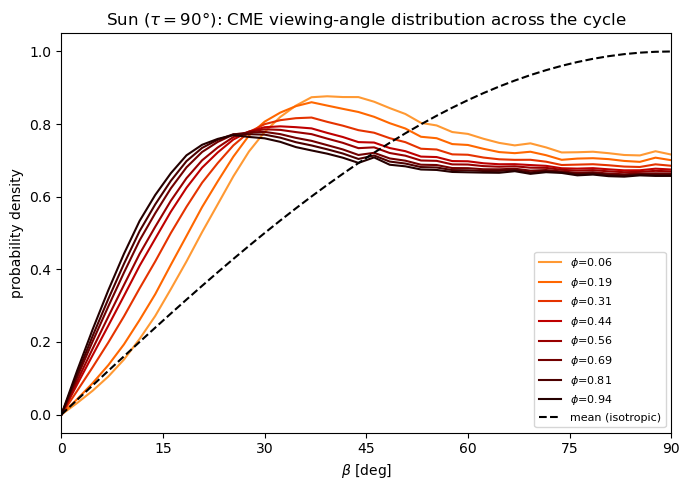

In [11]:
cmap = plt.get_cmap("gist_heat_r")
colors = cmap(np.linspace(0.2, 0.9, n_phase_bins))

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(n_phase_bins):
    area = np.trapz(dens_by_phase[k], betas_grid)
    ax.plot(betas_grid, dens_by_phase[k] / area, color=colors[k],
            label=fr"$\phi$={phase_centers[k]:.2f}")
ax.plot(betas_grid, np.sin(betas_grid), "--", color="black", label="mean (isotropic)")
ax.set_xticks(np.linspace(0, np.pi / 2, 7))
ax.set_xticklabels(range(0, 91, 15))
ax.set_xlim(0, np.pi / 2)
ax.set_xlabel(r"$\beta$ [deg]")
ax.set_ylabel("probability density")
ax.set_title(r"Sun ($\tau=90°$): CME viewing-angle distribution across the cycle")
ax.legend(fontsize=8)
plt.tight_layout()
Path("Figures").mkdir(exist_ok=True)
plt.savefig("Figures/latitude_time_beta_dist_vs_phase.pdf")
plt.show()


### Consistency check: does the activity-weighted average reproduce the repo's global fit?

As a sanity check tying this back to the rest of the repository: averaging the eight phase-resolved
$\rho_\beta(\beta)$ curves above, weighted by how much activity actually occurs at each phase (i.e. by
`counts_per_phase`), should reproduce the single curve obtained by plugging the global
$(\sigma,\nu)$ fit (fit to the *entire*, phase-pooled dataset) into the same estimator — since that's
exactly what the global fit already averages over.

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_8536\2317364062.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dens_weighted_avg /= np.trapz(dens_weighted_avg, betas_grid)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_8536\2317364062.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dens_global /= np.trapz(dens_global, betas_grid)


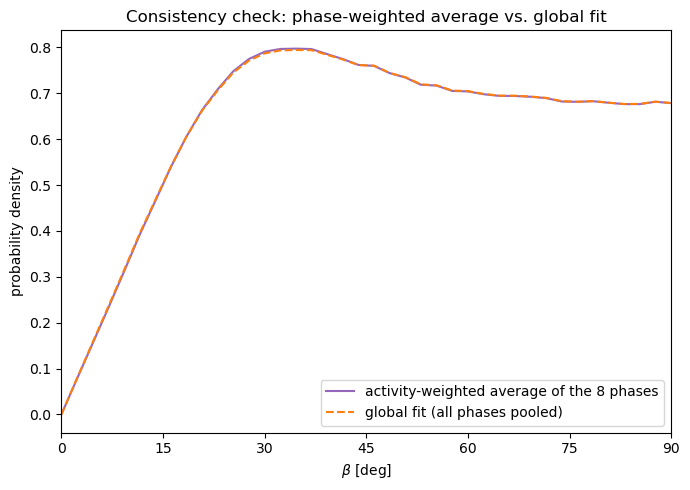

max relative difference between the two curves: 0.5% of the peak density


In [12]:
weights = counts_per_phase / counts_per_phase.sum()
dens_weighted_avg = np.average(dens_by_phase, axis=0, weights=weights)
dens_weighted_avg /= np.trapz(dens_weighted_avg, betas_grid)

rho_global = make_rho(sigma_fit_global, nu_fit_global)
dens_global = get_or_create_data("solar_cycle_beta_global",
                                  lambda: mc_rho_betas(betas_grid, tau_sun, rho_global))
dens_global /= np.trapz(dens_global, betas_grid)

rel_diff = np.max(np.abs(dens_weighted_avg - dens_global)) / np.max(dens_global) * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(betas_grid, dens_weighted_avg, color="tab:purple", label="activity-weighted average of the 8 phases")
ax.plot(betas_grid, dens_global, "--", color="tab:orange", label="global fit (all phases pooled)")
ax.set_xticks(np.linspace(0, np.pi / 2, 7))
ax.set_xticklabels(range(0, 91, 15))
ax.set_xlim(0, np.pi / 2)
ax.set_xlabel(r"$\beta$ [deg]")
ax.set_ylabel("probability density")
ax.set_title("Consistency check: phase-weighted average vs. global fit")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/latitude_time_beta_dist_consistency_check.pdf")
plt.show()

print(f"max relative difference between the two curves: {rel_diff:.1f}% of the peak density")


## Take-away (sections 6-7)

- Folding all 13 real cycles (lengths 9.7-12.5 yr, mean 10.9 yr) onto a common phase axis gives a
  single, high-statistics "average solar cycle" — 5,600-54,000 entries per phase bin, comfortably
  enough for a stable per-phase Rice fit.
- The fitted Rice $|\nu|$ (essentially the cycle's typical active-region latitude) drops **monotonically
  and substantially across the average cycle, from ≈22° shortly after minimum down to ≈7° just before
  the next minimum** — a factor of ~3 — crossing the repo-wide global-fit value (10.5°, dashed line
  above) around the cycle's midpoint. $\sigma$ varies more mildly, roughly 5-7.5°, and stays below the
  global fit's 9.0° throughout (pooling all phases together inflates $\sigma$, since it also has to
  absorb the phase-to-phase drift in $\nu$ that a single-phase fit doesn't need to).
- **Quantifying how wrong the single, phase-pooled "global" fit is**: comparing it to each phase's own
  fit uncertainty (1σ error bars from `curve_fit`'s covariance matrix, above), the global $\sigma$ is
  **5.4-20.4σ** away from the true per-phase value depending on cycle phase, and the global $\nu$ is
  **2.6-42.5σ** away — i.e. the single time-averaged fit used throughout the rest of this repository is
  statistically inconsistent with the actual distribution at *every* phase of the cycle, not just at
  the extremes. Even the phase where the global fit does best ($\nu$ at phase ≈0.44-0.56, near the
  crossing point in the plot above) still misses by several sigma; well away from that crossing
  (e.g. early in the cycle, $\phi\approx0.19$) the global fit is off by more than 40 standard errors.
- Plugging each phase's $(\sigma,\nu)$ into the *same* corrected geometric reduction used throughout
  this repository shows the **Sun's CME viewing-angle distribution ($\tau=90°$) genuinely changes
  shape over the cycle**, not just the total CME rate: early-cycle (high-latitude) phases give a
  broader $\rho_\beta(\beta)$ peaking around $\beta\approx45°$, while late-cycle (low-latitude) phases
  rise more steeply at small $\beta$ and peak closer to $\beta\approx35°$ — i.e. an equator-on observer
  should expect a somewhat higher fraction of small-$\beta$, high-Doppler-shift CMEs late in the cycle
  than early in it, purely from geometry.
- As a consistency check tying this back to the rest of the repository: weighting the eight
  phase-resolved $\rho_\beta(\beta)$ curves by how much activity actually occurs at each phase and
  averaging them reproduces the single curve from the repo's global, phase-pooled $(\sigma,\nu)$ fit
  to within **0.5%** of the peak density — as it should, since the global fit already averages over
  every phase. (This isn't in tension with the previous point: the global $\rho_\beta(\beta)$ curve is
  still a good *activity-weighted average* over the cycle, it's specifically the underlying
  $(\sigma,\nu)$ parameters that are a poor description of any single phase.)